Import Necessary Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import seaborn as sns

plt.style.use("default")
sns.set(font_scale=1.1)

Load the Data Set

In [2]:
from google.colab import files

import pandas as pd

df = pd.read_excel(
    "/content/NHS Inequality Project.xlsx",
    sheet_name="4",
    skiprows=6
)



In [3]:
df.head()

,Period,IMD decile,Sex,Sex code,Age group,Age code,HLE,LCI,UCI,Proportion (%)
0,2013 to 2015,1,Male,1,<1,1,52.1,51.5,52.6,70
1,2013 to 2015,1,Male,1,01 to 04,2,51.4,50.9,52.0,70
2,2013 to 2015,1,Male,1,05 to 09,3,47.7,47.2,48.2,69
3,2013 to 2015,1,Male,1,10 to 14,4,43.1,42.6,43.5,67
4,2013 to 2015,1,Male,1,15 to 19,5,38.5,38.1,38.9,65


Data Audit

In [4]:
#dataset shape(number of rows and Columns)
print(df.shape)

(4000, 10)


In [5]:
#data type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Period          4000 non-null   object 
 1   IMD decile      4000 non-null   int64  
 2   Sex             4000 non-null   object 
 3   Sex code        4000 non-null   int64  
 4   Age group       4000 non-null   object 
 5   Age code        4000 non-null   int64  
 6   HLE             4000 non-null   float64
 7   LCI             4000 non-null   float64
 8   UCI             4000 non-null   float64
 9   Proportion (%)  4000 non-null   int64  
dtypes: float64(3), int64(4), object(3)
memory usage: 312.6+ KB


In [6]:
#Missing Values
df.isnull().sum()

,0
Period,0
IMD decile,0
Sex,0
Sex code,0
Age group,0
Age code,0
HLE,0
LCI,0
UCI,0
Proportion (%),0


In [7]:
#Duplicate rows
df.duplicated().sum()

np.int64(0)

In [8]:
#Overall Statistics of the dataset
df.describe().T

,count,mean,std,min,25%,50%,75%,max
IMD decile,4000.0,5.500000,2.872640,1.0,3.00,5.50,8.000,10.0
Sex code,4000.0,1.500000,0.500063,1.0,1.00,1.50,2.000,2.0
Age code,4000.0,10.500000,5.767002,1.0,5.75,10.50,15.250,20.0
HLE,4000.0,28.608725,21.040136,0.7,8.90,25.65,46.900,71.3
LCI,4000.0,28.143525,20.941290,0.5,8.50,25.15,46.425,70.7
UCI,4000.0,29.075175,21.140119,0.8,9.30,26.10,47.400,71.9
Proportion (%),4000.0,61.032250,15.351796,18.0,50.00,64.00,74.000,85.0


# **Data Cleaning & Preparation**

In [9]:
df_clean = df.copy()

Standardise Column Names

In [10]:
df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(", "")
    .str.replace(")", "")
    .str.replace("%", "percent")
)

df_clean.columns

Index(['period', 'imd_decile', 'sex', 'sex_code', 'age_group', 'age_code',
       'hle', 'lci', 'uci', 'proportion_percent'],
      dtype='object')

Removing the encoded columns

In [11]:
df_clean.drop(
    columns=['sex_code', 'age_code'],
    inplace=True
)

In [12]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   period              4000 non-null   object 
 1   imd_decile          4000 non-null   int64  
 2   sex                 4000 non-null   object 
 3   age_group           4000 non-null   object 
 4   hle                 4000 non-null   float64
 5   lci                 4000 non-null   float64
 6   uci                 4000 non-null   float64
 7   proportion_percent  4000 non-null   int64  
dtypes: float64(3), int64(2), object(3)
memory usage: 250.1+ KB


In [13]:
df_clean.columns

Index(['period', 'imd_decile', 'sex', 'age_group', 'hle', 'lci', 'uci',
       'proportion_percent'],
      dtype='object')

# Exploratory Data Analysis (EDA)

**Analysis Question 1**

**Does Healthy Life Expectancy vary by deprivation level?**

*Calculate Average HLE by IMD Decile*

In [14]:
imd_hle = (
    df_clean.groupby('imd_decile')['hle']
    .mean()
    .reset_index()
)

imd_hle

,imd_decile,hle
0,1,21.27475
1,2,23.95600
2,3,25.83100
3,4,27.57200
4,5,29.16550
5,6,29.88425
6,7,30.83400
7,8,31.59450
8,9,32.33850
9,10,33.63675


*Visualization*

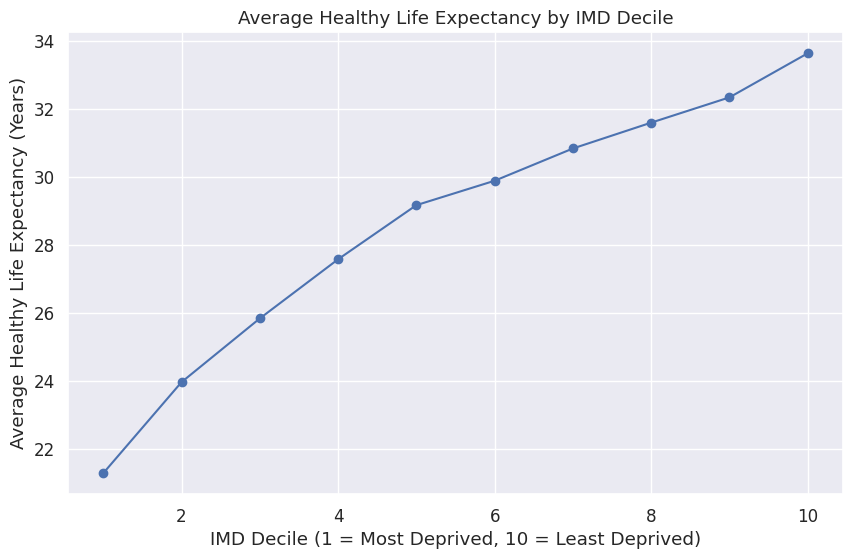

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(
    imd_hle['imd_decile'],
    imd_hle['hle'],
    marker='o'
)

plt.title('Average Healthy Life Expectancy by IMD Decile')
plt.xlabel('IMD Decile (1 = Most Deprived, 10 = Least Deprived)')
plt.ylabel('Average Healthy Life Expectancy (Years)')
plt.grid(True)
plt.tight_layout
plt.show()

*Measure the Health Inequality Gap*

In [16]:
least_deprived = imd_hle.loc[
    imd_hle['imd_decile'] == 10,
    'hle'
].values[0]

most_deprived = imd_hle.loc[
    imd_hle['imd_decile'] == 1,
    'hle'
].values[0]

gap = least_deprived - most_deprived

print(f"HLE Gap: {gap:.2f} years")

HLE Gap: 12.36 years


**Insight**

Healthy Life Expectancy showed a strong positive relationship with deprivation decile. Individuals living in the least deprived areas (IMD Decile 10) experienced an average Healthy Life Expectancy of 33.64 years compared with 21.27 years among those living in the most deprived areas (IMD Decile 1). This represents a health inequality gap of approximately 12.36 years. The consistent upward trend across all deprivation deciles suggests that socioeconomic deprivation is strongly associated with poorer health outcomes and fewer years lived in good health.


**Question 2**

**Do males and females experience different Healthy Life Expectancy outcomes?**

Healthy Life Expectancy by sex

In [17]:
sex_hle = (
    df_clean.groupby('sex')['hle']
    .mean()
    .reset_index()
)

sex_hle

,sex,hle
0,Female,29.02200
1,Male,28.19545


Visualization

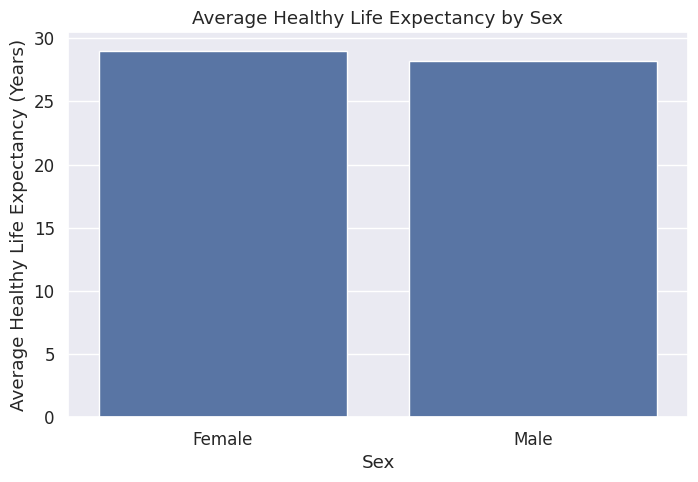

In [18]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=sex_hle,
    x='sex',
    y='hle'
)

plt.title('Average Healthy Life Expectancy by Sex')
plt.xlabel('Sex')
plt.ylabel('Average Healthy Life Expectancy (Years)')
plt.tight_layout
plt.show()

Difference

In [19]:
female_hle = sex_hle.loc[
    sex_hle['sex'] == 'Female',
    'hle'
].values[0]

male_hle = sex_hle.loc[
    sex_hle['sex'] == 'Male',
    'hle'
].values[0]

print(f"Difference: {female_hle - male_hle:.2f} years")

Difference: 0.83 years


**Insight**

Female individuals experienced a slightly higher average Healthy Life Expectancy (29.02 years) than males (28.20 years), representing a difference of approximately 0.83 years. While a gender disparity exists, its magnitude is substantially smaller than the inequality observed across deprivation levels. This suggests that socioeconomic deprivation may be a stronger determinant of Healthy Life Expectancy than sex within this dataset.


**Question 3**

**How does Healthy Life Expectancy change across age groups?**

In [20]:
age_hle = (
    df_clean.groupby('age_group')['hle']
    .mean()
    .reset_index()
)

age_hle

,age_group,hle
0,01 to 04,62.1270
1,05 to 09,58.3855
2,10 to 14,53.7370
3,15 to 19,49.1320
4,20 to 24,44.6410
5,25 to 29,40.2775
6,30 to 34,35.9765
7,35 to 39,31.7715
8,40 to 44,27.7035
9,45 to 49,23.8010


In [21]:
df_clean['age_group'].unique()

array(['<1', '01 to 04', '05 to 09', '10 to 14', '15 to 19', '20 to 24',
       '25 to 29', '30 to 34', '35 to 39', '40 to 44', '45 to 49',
       '50 to 54', '55 to 59', '60 to 64', '65 to 69', '70 to 74',
       '75 to 79', '80 to 84', '85 to 89', '90+'], dtype=object)

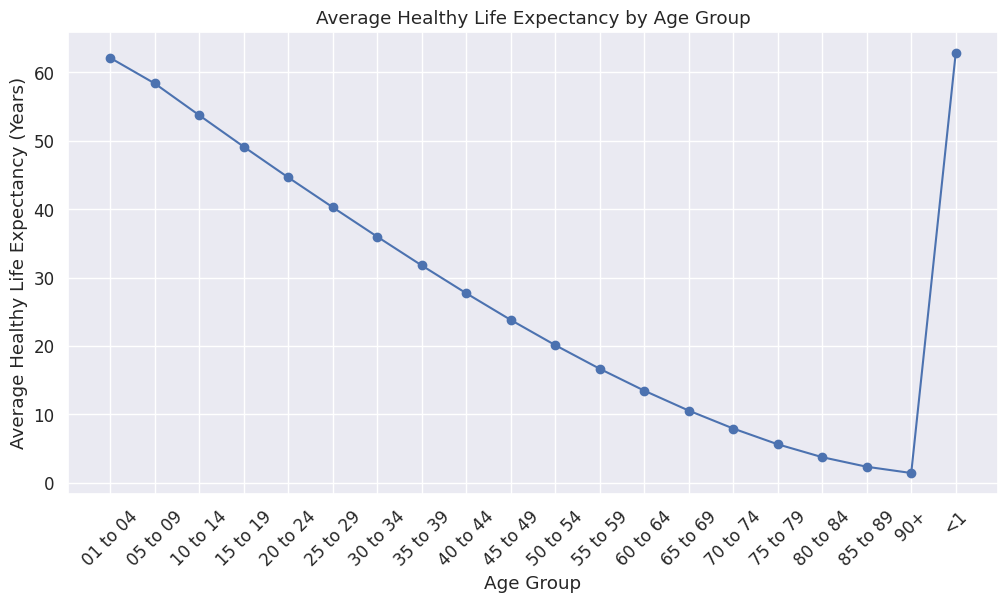

In [22]:
plt.figure(figsize=(12,6))

plt.plot(
    age_hle['age_group'],
    age_hle['hle'],
    marker='o'
)

plt.title('Average Healthy Life Expectancy by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Healthy Life Expectancy (Years)')
plt.xticks(rotation=45)
plt.tight_layout
plt.show()

**Insight**
Healthy Life Expectancy declines progressively across age groups, falling from approximately 62.84 years among infants (<1 year) to 1.41 years among individuals aged 90 years and above. The decline follows a consistent downward trajectory, reflecting the natural reduction in remaining years expected to be lived in good health as age increases. The absence of major fluctuations suggests a stable age-related pattern within the population.


**Question 4**

**Does the deprivation gap affect males and females differently?**

Deprivation × Sex Interaction

In [23]:
sex_imd = (
    df_clean.groupby(['imd_decile', 'sex'])['hle']
    .mean()
    .reset_index()
)

sex_imd.head()

,imd_decile,sex,hle
0,1,Female,21.4275
1,1,Male,21.1220
2,2,Female,24.2195
3,2,Male,23.6925
4,3,Female,26.2260


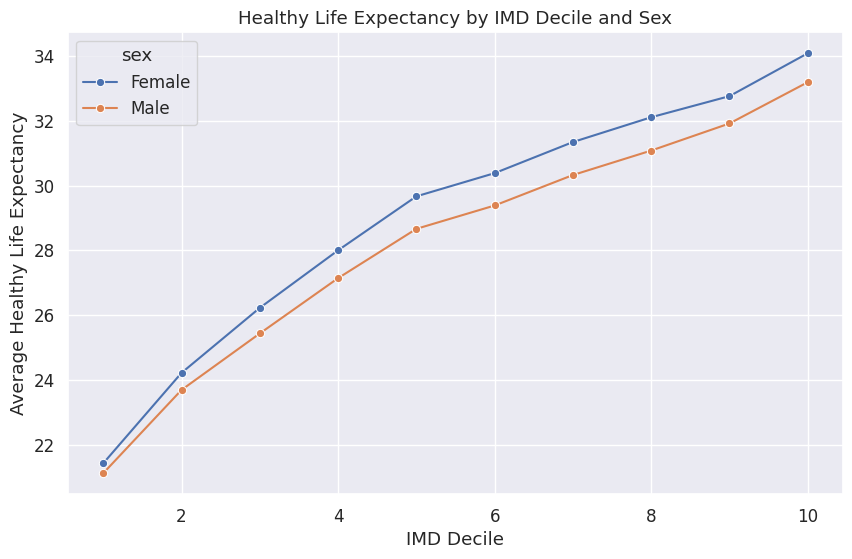

In [24]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=sex_imd,
    x='imd_decile',
    y='hle',
    hue='sex',
    marker='o'
)

plt.title('Healthy Life Expectancy by IMD Decile and Sex')
plt.xlabel('IMD Decile')
plt.ylabel('Average Healthy Life Expectancy')
plt.tight_layout
plt.show()

**Insight**
Analysis by deprivation decile and sex revealed that Healthy Life Expectancy increases consistently across deprivation levels for both males and females. Females maintained a modest advantage in Healthy Life Expectancy at every deprivation decile; however, the difference between sexes remained relatively small. The nearly parallel trends suggest that deprivation exerts a similar influence on both genders. Overall, socioeconomic deprivation appears to have a substantially greater impact on Healthy Life Expectancy than sex.


**Trends Over Time**

*Has Healthy Life Expectancy improved over time?*

In [25]:
df_clean['period'].unique()

array(['2013 to 2015', '2014 to 2016', '2015 to 2017', '2016 to 2018',
       '2017 to 2019', '2018 to 2020', '2019 to 2021', '2020 to 2022',
       '2021 to 2023', '2022 to 2024'], dtype=object)

Calculate Average HLE by Period

In [26]:
period_hle = (
    df_clean.groupby('period')['hle']
    .mean()
    .reset_index()
)

period_hle

,period,hle
0,2013 to 2015,28.73125
1,2014 to 2016,28.74725
2,2015 to 2017,28.76925
3,2016 to 2018,28.88575
4,2017 to 2019,28.78300
5,2018 to 2020,28.94350
6,2019 to 2021,28.84625
7,2020 to 2022,28.47650
8,2021 to 2023,28.06050
9,2022 to 2024,27.84400


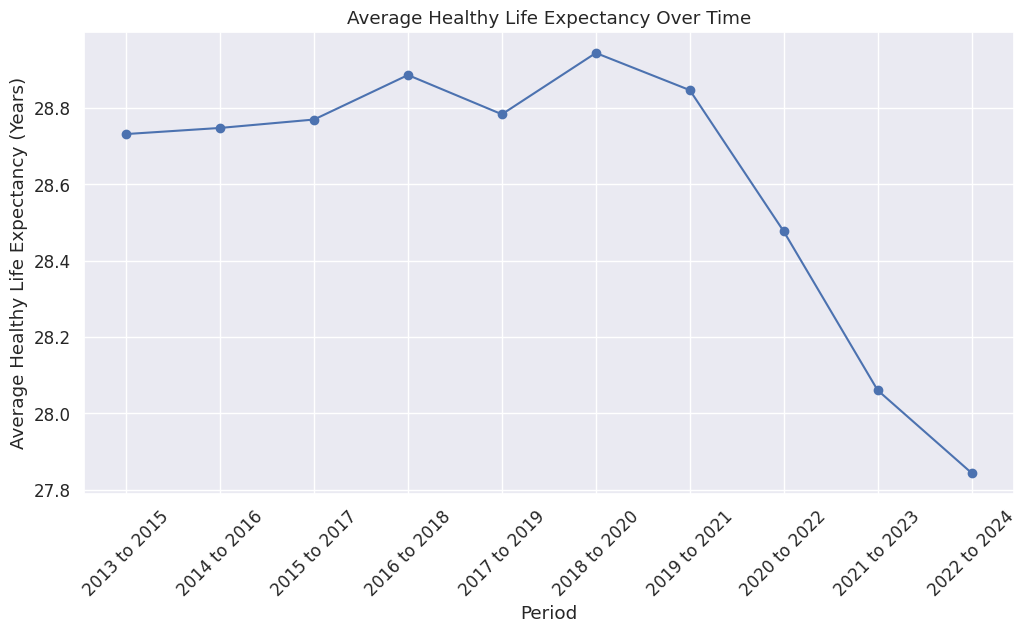

In [27]:
plt.figure(figsize=(12,6))

plt.plot(
    period_hle['period'],
    period_hle['hle'],
    marker='o'
)

plt.title('Average Healthy Life Expectancy Over Time')
plt.xlabel('Period')
plt.ylabel('Average Healthy Life Expectancy (Years)')
plt.xticks(rotation=45)

plt.show()

**Insight**
Average Healthy Life Expectancy remained broadly stable between 2013–2015 and 2018–2020, showing only minor year-to-year variation. However, a sustained decline emerged from 2019–2021 onwards, with the most pronounced reductions occurring in the latest reporting periods. By 2022–2024, average Healthy Life Expectancy had fallen by approximately 1.1 years compared with its peak level. This pattern suggests a deterioration in population health outcomes during the latter part of the study period.


**The Health Inequality Gap Over Time**

In [28]:
gap_over_time = (
    df_clean.groupby(['period', 'imd_decile'])['hle']
    .mean()
    .reset_index()
)

Calculate the gap:

In [29]:
gap_table = gap_over_time.pivot(
    index='period',
    columns='imd_decile',
    values='hle'
)

gap_table['inequality_gap'] = (
    gap_table[10] - gap_table[1]
)

gap_table[['inequality_gap']]

imd_decile,inequality_gap
period,
2013 to 2015,12.3050
2014 to 2016,12.2900
2015 to 2017,12.0475
2016 to 2018,12.1675
2017 to 2019,12.3600
2018 to 2020,12.1050
2019 to 2021,12.1350
2020 to 2022,12.4550
2021 to 2023,12.8825


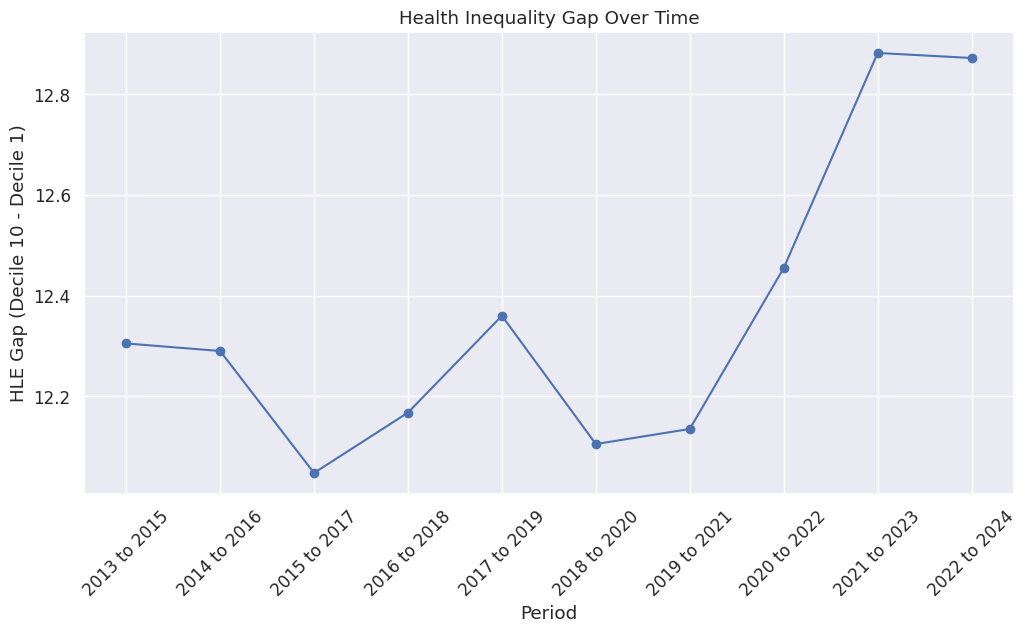

In [30]:
plt.figure(figsize=(12,6))

plt.plot(
    gap_table.index,
    gap_table['inequality_gap'],
    marker='o'
)

plt.title('Health Inequality Gap Over Time')
plt.xlabel('Period')
plt.ylabel('HLE Gap (Decile 10 - Decile 1)')
plt.xticks(rotation=45)
plt.tight_layout
plt.show()

**Insight**
Analysis of the deprivation gap over time revealed that health inequalities have widened during the study period. While the Healthy Life Expectancy gap between the least deprived and most deprived populations remained relatively stable between 2013–2015 and 2019–2021, a noticeable increase occurred in the most recent periods. The inequality gap rose from approximately 12.31 years in 2013–2015 to 12.87 years in 2022–2024. Combined with the overall decline in Healthy Life Expectancy observed during the same period, these findings suggest that population health has deteriorated while disparities between socioeconomic groups have become more pronounced.


**Correlation Between Deprivation and Healthy Life Expectancy**

In [31]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(
    df_clean['imd_decile'],
    df_clean['hle']
)

print("Correlation:", round(corr, 3))
print("P-value:", p_value)

Correlation: 0.173
P-value: 2.7034592333302387e-28


Correct Analysis

In [32]:
corr, p_value = pearsonr(
    imd_hle['imd_decile'],
    imd_hle['hle']
)

print("Correlation:", round(corr, 3))
print("P-value:", p_value)

Correlation: 0.976
P-value: 1.3474398097818448e-06


A Pearson correlation analysis was conducted to assess the relationship between deprivation level (IMD decile) and Healthy Life Expectancy. The analysis revealed an extremely strong positive correlation (r = 0.976, p < 0.001), indicating that Healthy Life Expectancy increases substantially as deprivation decreases. The result was statistically significant, suggesting that socioeconomic deprivation is strongly associated with differences in population health outcomes.


gender gap correlation

In [33]:
sex_hle

female_hle = sex_hle.loc[sex_hle['sex']=='Female','hle'].iloc[0]
male_hle = sex_hle.loc[sex_hle['sex']=='Male','hle'].iloc[0]

gender_gap = female_hle - male_hle

print(f"Gender Gap: {gender_gap:.2f} years")

Gender Gap: 0.83 years


# Create the Executive Summary Table

In [34]:
avg_hle = round(df_clean['hle'].mean(), 2)

deprivation_gap = round(
    imd_hle.loc[imd_hle['imd_decile']==10,'hle'].iloc[0]
    -
    imd_hle.loc[imd_hle['imd_decile']==1,'hle'].iloc[0],
    2
)

gender_gap = round(
    sex_hle.loc[sex_hle['sex']=='Female','hle'].iloc[0]
    -
    sex_hle.loc[sex_hle['sex']=='Male','hle'].iloc[0],
    2
)

latest_hle = round(
    period_hle.loc[
        period_hle['period']=='2022 to 2024',
        'hle'
    ].iloc[0],
    2
)

summary = pd.DataFrame({
    'Metric': [
        'Average HLE',
        'Deprivation Gap',
        'Gender Gap',
        'Latest HLE'
    ],
    'Value': [
        avg_hle,
        deprivation_gap,
        gender_gap,
        latest_hle
    ]
})

summary

,Metric,Value
0,Average HLE,28.61
1,Deprivation Gap,12.36
2,Gender Gap,0.83
3,Latest HLE,27.84


Export All Tables as CSV Files

In [35]:
imd_hle.to_csv('imd_hle.csv', index=False)

sex_hle.to_csv('sex_hle.csv', index=False)

age_hle.to_csv('age_hle.csv', index=False)

period_hle.to_csv('period_hle.csv', index=False)

summary.to_csv('summary.csv', index=False)

gap_table[['inequality_gap']].reset_index().to_csv(
    'inequality_gap.csv',
    index=False
)

print("CSV files created successfully!")

CSV files created successfully!


In [36]:
import os

os.listdir()

['.config',
 'imd_hle.csv',
 'inequality_gap.csv',
 'sex_hle.csv',
 'summary.csv',
 'age_hle.csv',
 'NHS Inequality Project.xlsx',
 'period_hle.csv',
 'sample_data']

Download the CSV Files

In [37]:
from google.colab import files

files.download('summary.csv')
files.download('imd_hle.csv')
files.download('sex_hle.csv')
files.download('age_hle.csv')
files.download('period_hle.csv')
files.download('inequality_gap.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Create Chronological Sort Order for Trend Analysis

In [38]:
period_hle['period_order'] = range(1, 11)

period_hle

,period,hle,period_order
0,2013 to 2015,28.73125,1
1,2014 to 2016,28.74725,2
2,2015 to 2017,28.76925,3
3,2016 to 2018,28.88575,4
4,2017 to 2019,28.78300,5
5,2018 to 2020,28.94350,6
6,2019 to 2021,28.84625,7
7,2020 to 2022,28.47650,8
8,2021 to 2023,28.06050,9
9,2022 to 2024,27.84400,10


Create Chronological Sort Order for Health Inequality Gap Analysis

In [39]:
inequality_gap_export = gap_table[['inequality_gap']].reset_index()

inequality_gap_export['period_order'] = range(1, 11)

inequality_gap_export

imd_decile,period,inequality_gap,period_order
0,2013 to 2015,12.3050,1
1,2014 to 2016,12.2900,2
2,2015 to 2017,12.0475,3
3,2016 to 2018,12.1675,4
4,2017 to 2019,12.3600,5
5,2018 to 2020,12.1050,6
6,2019 to 2021,12.1350,7
7,2020 to 2022,12.4550,8
8,2021 to 2023,12.8825,9
9,2022 to 2024,12.8725,10


Export Updated Trend Analysis Files for Power BI

In [40]:
period_hle.to_csv('period_hle.csv', index=False)

inequality_gap_export.to_csv('inequality_gap.csv', index=False)

print("Updated files created successfully!")

Updated files created successfully!


Download Updated Dashboard Files

In [41]:
from google.colab import files

files.download('period_hle.csv')
files.download('inequality_gap.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>